In [19]:
# This package is required to fetch the benchmark suit mentioned in the seed paper
# uncomment if not installed already
# !pip install openml

In [20]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
import math
import torch.nn as nn
import torch.nn.functional as F

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ",device)

Using device:  cuda


In [22]:
import openml
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def get_openml_ctr23_dataset(index=0, test_size=0.2, random_state=0):
    """
    Loads and preprocesses the OpenML-CTR23 regression dataset at the given index.
    Automatically separates numeric vs. categorical features,
    one-hot-encodes all categoricals, standard-scales the numerics,
    and returns train/test splits.
    """
    # 1. Fetch the task ID from the CTR23 suite
    suite = openml.study.get_suite(353)
    task_id = suite.tasks[index]
    task = openml.tasks.get_task(task_id)
    dataset = task.get_dataset()
    
    # 2. Extract raw X, y, and feature names
    X_raw, y_raw, _, feature_names = dataset.get_data(target=task.target_name)
    X_df = pd.DataFrame(X_raw, columns=feature_names)
    y = np.array(y_raw, dtype=float)
    
    # 3. Infer column types via pandas dtypes
    num_cols = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
    
    # 4. Building a ColumnTransformer
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols
        )
    ])
    
    X_processed = preprocessor.fit_transform(X_df)
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=test_size, random_state=random_state
    )
    return X_train, X_test, y_train, y_test

In [23]:
import numpy as np
from scipy.stats import kendalltau

def calculate_metrics(y_pred, y_true):
    # Convert inputs to numpy arrays of float64 to handle large values
    y_pred = np.asarray(y_pred, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.float64)
    
    # Check if shapes are compatible
    if y_pred.shape != y_true.shape:
        raise ValueError("y_pred and y_true must have the same shape.")
    
    # Create a mask to filter out non-finite values (NaN, Inf)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    # Number of valid samples after filtering
    n_valid = y_true_clean.size
    
    # Handle case with no valid samples
    if n_valid == 0:
        return {
            'tau': np.nan,
            'mse': np.nan,
            'mae': np.nan,
            'r2': np.nan,
            'n_valid_samples': 0
        }
    
    # Calculate Kendall's Tau (requires at least 2 samples)
    if n_valid < 2:
        tau = np.nan
    else:
        tau, _ = kendalltau(y_true_clean, y_pred_clean)
    
    # Calculate differences
    diff = y_true_clean - y_pred_clean
    
    # Calculate MSE with overflow handling
    squared_diff = diff ** 2
    if np.any(np.isinf(squared_diff)):
        mse = np.inf
    else:
        mse = np.mean(squared_diff)
    
    # Calculate MAE (no overflow risk with finite differences)
    mae = np.mean(np.abs(diff))
    
    # Calculate R² score
    if n_valid < 2:
        r2 = np.nan  # R² undefined for a single sample
    else:
        ss_total = np.var(y_true_clean, ddof=0) * n_valid  # Total sum of squares
        if ss_total == 0:
            # All true values are identical
            r2 = 1.0 if np.all(diff == 0) else 0.0
        else:
            ss_residual = np.sum(squared_diff)
            r2 = 1 - (ss_residual / ss_total)
    
    print(f"10 preds (valid): {y_pred_clean[:10]}")
    print(f"10 trues (valid): {y_true_clean[:10]}")
    
    return {
        'tau': tau,
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'n_valid_samples': n_valid
    }

In [24]:
# import math
# import sys

# class Tokenizer:
#     def __init__(self, base=10, exp_digits=3, man_digits=4):
#         self.base = base
#         self.exp_digits = exp_digits
#         self.man_digits = man_digits
#         self.tokens = ['<BOS>', '<EOS>', '+', '-'] + [str(i) for i in range(base)]
#         self.token2idx = {tok: i for i, tok in enumerate(self.tokens)}
#         self.idx2token = {i: tok for tok, i in self.token2idx.items()}
        
#         # Precompute maximum safe exponent to prevent overflow
#         self.max_safe_exp = math.floor(math.log(sys.float_info.max) / math.log(base)) if base > 1 else 0

#     def encode(self, v: float) -> list[int]:
#         """Encode float v → list of token indices (no <BOS>, includes <EOS>)."""
#         # 1) sign
#         sign_tok = self.token2idx['+'] if v >= 0 else self.token2idx['-']
#         v_abs = abs(v)
#         # 2) handle zero
#         if v_abs == 0.0:
#             exp_val, exp_sign_tok, man_int = 0, self.token2idx['+'], 0
#         else:
#             # exponent (base-10) as integer
#             exp_val = int(math.floor(math.log10(v_abs)))
#             exp_sign_tok = self.token2idx['+'] if exp_val >= 0 else self.token2idx['-']
#             exp_val = abs(exp_val)
#             # clamp exponent
#             max_exp = self.base**self.exp_digits - 1
#             if exp_val > max_exp:
#                 exp_val = max_exp
#             # mantissa scaled to integer
#             mantissa = v_abs / (self.base ** (exp_val if exp_sign_tok == self.token2idx['+'] else -exp_val))
#             man_int = int(math.floor(mantissa * (self.base ** (self.man_digits - 1))))
#             max_man = self.base**self.man_digits - 1
#             if man_int > max_man:
#                 man_int = max_man

#         # 3) digitize exponent and mantissa
#         exp_digits = []
#         for i in reversed(range(self.exp_digits)):
#             exp_digits.append((exp_val // (self.base**i)) % self.base)
#         man_digits = []
#         for i in reversed(range(self.man_digits)):
#             man_digits.append((man_int // (self.base**i)) % self.base)

#         # 4) mapping digits → token indices 
#         seq = [sign_tok, exp_sign_tok]
#         seq += [d + 4 for d in exp_digits]
#         seq += [d + 4 for d in man_digits]
#         seq.append(self.token2idx['<EOS>'])
#         return seq
        
#     def decode(self, idx_seq: list[int]) -> float:
#         """Decode token-index list (no <BOS>) back to float."""
#         if len(idx_seq) < 2:
#             return 0.0
        
#         # 1) Sign handling
#         sign = -1.0 if idx_seq[0] == self.token2idx['-'] else 1.0
        
#         # 2) Exponent sign and value
#         exp_sign = -1 if idx_seq[1] == self.token2idx['-'] else 1
#         exp_val = 0
#         for i in range(self.exp_digits):
#             exp_val = exp_val * self.base + (idx_seq[2 + i] - 4)
        
#         # 3) Mantissa calculation
#         man_val = 0
#         start = 2 + self.exp_digits
#         for j in range(self.man_digits):
#             man_val = man_val * self.base + (idx_seq[start + j] - 4)
#         mantissa = man_val / (self.base ** (self.man_digits - 1))
        
#         # 4) Safe exponentiation
#         actual_exp = exp_sign * exp_val
        
#         # Clamping exponent to prevent overflow
#         if actual_exp > self.max_safe_exp:
#             actual_exp = self.max_safe_exp
        
#         try:
#             # Computing using floating-point exponentiation
#             base_exp = math.pow(self.base, actual_exp)
#             result = sign * mantissa * base_exp
            
#             # Final overflow check (sometimes i got erros during training)
#             # Also because we're trying without data normalization (for generalibility of this model in usecases, please refer: report)
#             if not math.isfinite(result):
#                 return sign * sys.float_info.max
#             return result
#         except OverflowError:
#             return sign * sys.float_info.max

import math
import sys

class Tokenizer:
    def __init__(self, base=10, exp_digits=3, man_digits=4):
        self.base = base
        self.exp_digits = exp_digits
        self.man_digits = man_digits
        self.tokens = ['<BOS>', '<EOS>', '+', '-'] + [str(i) for i in range(base)]
        self.token2idx = {tok: i for i, tok in enumerate(self.tokens)}
        self.idx2token = {i: tok for tok, i in self.token2idx.items()}
        # Precompute maximum safe exponent to prevent overflow
        self.max_safe_exp = math.floor(math.log(sys.float_info.max) / math.log(base)) if base > 1 else 0

    def encode(self, v: float) -> list[int]:
        """(unchanged) Encode float v → list of token indices (no <BOS>, includes <EOS>)."""
        sign_tok = self.token2idx['+'] if v >= 0 else self.token2idx['-']
        v_abs = abs(v)
        if v_abs == 0.0:
            exp_val, exp_sign_tok, man_int = 0, self.token2idx['+'], 0
        else:
            exp_val = int(math.floor(math.log10(v_abs)))
            exp_sign_tok = self.token2idx['+'] if exp_val >= 0 else self.token2idx['-']
            exp_val = abs(exp_val)
            max_exp = self.base**self.exp_digits - 1
            exp_val = min(exp_val, max_exp)
            scale = self.base ** (exp_val if exp_sign_tok == self.token2idx['+'] else -exp_val)
            mantissa = v_abs / scale
            man_int = int(math.floor(mantissa * (self.base ** (self.man_digits - 1))))
            max_man = self.base**self.man_digits - 1
            man_int = min(man_int, max_man)

        exp_digits = [(exp_val // (self.base**i)) % self.base for i in reversed(range(self.exp_digits))]
        man_digits = [(man_int // (self.base**i)) % self.base for i in reversed(range(self.man_digits))]

        seq = [sign_tok, exp_sign_tok]
        seq += [d + 4 for d in exp_digits]
        seq += [d + 4 for d in man_digits]
        seq.append(self.token2idx['<EOS>'])
        return seq

    def decode(self, idx_seq: list[int]) -> float:
        """Robust decode: strip/pad to exactly 2+exp_digits+man_digits tokens, then original logic."""
        eos = self.token2idx['<EOS>']
        # 1) truncate at first EOS
        if eos in idx_seq:
            idx_seq = idx_seq[:idx_seq.index(eos)]
        # 2) pad with '0' digits (token index 4) if too short
        needed = 2 + self.exp_digits + self.man_digits
        if len(idx_seq) < needed:
            idx_seq += [4] * (needed - len(idx_seq))

        # original decoding logic
        sign = -1.0 if idx_seq[0] == self.token2idx['-'] else 1.0
        exp_sign = -1 if idx_seq[1] == self.token2idx['-'] else 1

        exp_val = 0
        for i in range(self.exp_digits):
            exp_val = exp_val * self.base + (idx_seq[2 + i] - 4)

        man_val = 0
        start = 2 + self.exp_digits
        for j in range(self.man_digits):
            man_val = man_val * self.base + (idx_seq[start + j] - 4)
        mantissa = man_val / (self.base ** (self.man_digits - 1))

        actual_exp = exp_sign * exp_val
        if actual_exp > self.max_safe_exp:
            actual_exp = self.max_safe_exp

        try:
            base_exp = math.pow(self.base, actual_exp)
            result = sign * mantissa * base_exp
            return result if math.isfinite(result) else sign * sys.float_info.max
        except OverflowError:
            return sign * sys.float_info.max

In [25]:
class DecodingRegressor(nn.Module):
    def __init__(self, input_dim, d_model, vocab_size, num_layers=2, nhead=4):
        super().__init__()
        # MLP encoder (shared encoder in MLP for comparing models)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2*d_model),
            nn.ReLU(),
            nn.Linear(2*d_model, d_model)
        )
        # Token and positional embeddings for decoder
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(100, d_model)  # support seq length up to ~100
        # Transformer decoder stack
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        # Final projection to vocab
        self.out = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def forward(self, X, tgt):
        """
        X: [batch, features], tgt: [batch, seq_len] token indices including <BOS> at index 0.
        Returns logits [seq_len, batch, vocab_size].
        """
        batch_size = X.size(0)
        # Encode features
        memory = self.encoder(X).unsqueeze(0)  # [1, batch, d_model] acts as "memory"
        # Prepare token embeddings + positional
        seq_len = tgt.size(1)
        positions = torch.arange(seq_len, device=X.device).unsqueeze(0).expand(batch_size, -1)
        tok_emb = self.token_emb(tgt) + self.pos_emb(positions)
        # Transformer expects [seq_len, batch, d_model]
        tok_emb = tok_emb.permute(1,0,2)
        # Causal mask so each position only sees previous tokens
        mask = torch.triu(torch.ones(seq_len, seq_len, device=X.device)==1, diagonal=1)
        mask = mask.float().masked_fill(mask, float('-inf'))
        # Decode
        dec_out = self.decoder(tok_emb, memory, tgt_mask=mask)
        logits = self.out(dec_out)
        return logits

In [26]:
from torch.utils.data import DataLoader, TensorDataset
def train_decoding_regression_model(tokenizer, X_train, y_train, num_epochs=50, batch_size=64, lr=1e-3):
    # Initialize model
    input_dim = X_train.shape[1]
    vocab_size = len(tokenizer.tokens)

    model = DecodingRegressor(input_dim, d_model=64, vocab_size=vocab_size)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Prepare token sequences for training
    train_tokens = [tokenizer.encode(float(v)) for v in y_train]
    max_len = max(len(seq) for seq in train_tokens)
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    Y_tensor = torch.full((len(train_tokens), max_len), tokenizer.token2idx['<EOS>'], dtype=torch.long)

    # Filling each row with the exact token sequence
    for i, seq in enumerate(train_tokens):
        # seq already includes its EOS at the end
        Y_tensor[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)

    # Create DataLoader
    train_loader = DataLoader(TensorDataset(X_tensor, Y_tensor), batch_size=64, shuffle=True)

    # Training loop with GPU (if there is...)
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_X, batch_Y in train_loader:
            # moviing data on GPU
            batch_X = batch_X.to(device)
            batch_Y = batch_Y.to(device)

            optimizer.zero_grad()
            # Building decoder input: prepend BOS and drop the last token of batch_Y
            bos_col = torch.full((batch_Y.size(0), 1), tokenizer.token2idx['<BOS>'], dtype=torch.long, device=device)
            tgt_input = torch.cat([bos_col, batch_Y[:, :-1]], dim=1)

            # Forward pass
            logits = model(batch_X, tgt_input)  # [seq_len, batch, vocab]
            seq_len, batch_size, V = logits.shape

            # Compute CE loss against the true tokens (including EOS in batch_Y)
            loss = criterion(
                logits.view(-1, V),
                batch_Y.transpose(0,1).reshape(-1)
            )
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch+1%10==0:
            print(f"Transformer: Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    return max_len, model

def eval_decoding_regression_model(model, tokenizer, X_test, max_len):
    input_dim = X_train.shape[1]
    vocab_size = len(tokenizer.tokens)

    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(len(X_test)):
            x = torch.tensor(X_test[i:i+1], dtype=torch.float32).to(device)
            cur_seq = [tokenizer.token2idx['<BOS>']]
            for _ in range(max_len):
                # Moving sequence tensor to GPU
                tgt = torch.tensor(cur_seq, dtype=torch.long).unsqueeze(0).to(device)
                logits = model(x, tgt)
                next_tok = logits.argmax(dim=-1)[-1,0].item()
                if next_tok == tokenizer.token2idx['<EOS>']:
                    break
                cur_seq.append(next_tok)
            # Remove BOS and decode
            pred_tokens = cur_seq[1:]
            pred_val = tokenizer.decode(pred_tokens)
            preds.append(pred_val)

    return preds

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class MLPDecodingRegressor(nn.Module):
    def __init__(self, input_dim, d_model, vocab_size, num_layers=2):
        super().__init__()
        # Shared encoder (unchanged)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2 * d_model),
            nn.ReLU(),
            nn.Linear(2 * d_model, d_model)
        )
        # Token and positional embeddings (unchanged)
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(100, d_model)

        layers = []
        for _ in range(num_layers):
            layers += [
                nn.Linear(2 * d_model, 4 * d_model),  
                nn.ReLU(),
                nn.Linear(4 * d_model, 2 * d_model), 
                nn.ReLU()
            ]
        layers.append(nn.Linear(2 * d_model, d_model)) 
        self.decoder_mlp = nn.Sequential(*layers)

        self.out = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def forward(self, X, tgt):
        """
        X: [batch, features], tgt: [batch, seq_len]
        Returns logits [seq_len, batch, vocab_size]
        """
        batch_size, seq_len = tgt.size()

        # Encode features to memory vector
        memory = self.encoder(X).unsqueeze(0)  # [1, batch, d_model]
        memory_rep = memory.expand(seq_len, batch_size, self.d_model)

        # Prepare token + positional embeddings
        positions = torch.arange(seq_len, device=X.device) \
                             .unsqueeze(0) \
                             .expand(batch_size, -1)
        tok_emb = self.token_emb(tgt) + self.pos_emb(positions)
        tok_emb = tok_emb.permute(1, 0, 2)                      

        # Combine token embeddings with memory
        combined = torch.cat([tok_emb, memory_rep], dim=2) # [seq_len, batch, 2*d_model]

        # Decode with the more complex MLP
        dec_out = self.decoder_mlp(combined)   # [seq_len, batch, d_model]

        # Project to vocabulary logits
        logits = self.out(dec_out)   # [seq_len, batch, vocab_size]
        return logits


def train_mlp_regression_model(tokenizer, X_train, y_train, num_epochs=50, batch_size=64, lr=1e-3):
    input_dim = X_train.shape[1]
    vocab_size = len(tokenizer.tokens)
    # Initialize model
    model = MLPDecodingRegressor(input_dim, d_model=64, vocab_size=vocab_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Tokenize targets
    train_tokens = [tokenizer.encode(float(v)) for v in y_train]
    max_len = max(len(seq) for seq in train_tokens)
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    Y_tensor = torch.full((len(train_tokens), max_len), tokenizer.token2idx['<EOS>'], dtype=torch.long)
    for i, seq in enumerate(train_tokens):
        Y_tensor[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_tensor, Y_tensor), batch_size=batch_size, shuffle=True)
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_X, batch_Y in train_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            bos = torch.full((batch_Y.size(0), 1), tokenizer.token2idx['<BOS>'], dtype=torch.long, device=device)
            tgt_input = torch.cat([bos, batch_Y[:, :-1]], dim=1)
            logits = model(batch_X, tgt_input)           # [seq_len, batch, vocab]
            seq_len, bs, V = logits.shape
            loss = criterion(logits.view(-1, V), batch_Y.transpose(0,1).reshape(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch+1%10==0:
            print(f"MLP: Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    return max_len , model

def eval_mlp_regression_model(model, tokenizer, X_test, max_len):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(len(X_test)):
            x = torch.tensor(X_test[i:i+1], dtype=torch.float32).to(device)
            cur_seq = [tokenizer.token2idx['<BOS>']]
            for _ in range(max_len):
                tgt = torch.tensor(cur_seq, dtype=torch.long).unsqueeze(0).to(device)
                logits = model(x, tgt)
                next_tok = logits.argmax(dim=-1)[-1,0].item()
                if next_tok == tokenizer.token2idx['<EOS>']:
                    break
                cur_seq.append(next_tok)
            pred_tokens = cur_seq[1:]
            preds.append(tokenizer.decode(pred_tokens))
    return preds


In [28]:
# Example usage
tokenizer = Tokenizer(base=10, exp_digits=3, man_digits=4)
tensor_from_float = torch.tensor(123.456, dtype=torch.float32)
seq = tokenizer.encode(tensor_from_float)
print([tokenizer.idx2token[i] for i in seq])

['+', '+', '0', '0', '2', '1', '2', '3', '4', '<EOS>']


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import time

t1 = time.time()
mlp_results = {}
transformer_results = {}
num_datasets = len(openml.study.get_suite(353).tasks)

for i in range(num_datasets):
    try:
        X_train, X_test, y_train, y_test = get_openml_ctr23_dataset(i)
        print(f"Dataset {i+1}/{num_datasets}: X_tr={X_train.shape}, X_te={X_test.shape}")

        # Transformer
        print("Starting decoding based regression model...")
        max_len, model = train_decoding_regression_model(tokenizer, X_train, y_train, num_epochs=20, batch_size=1024, lr=1e-3)
        y_pred = eval_decoding_regression_model(model, tokenizer, X_test, max_len)
        transformer_results[i] = calculate_metrics(y_pred, y_test.tolist())
    
        ###########################################################################
        #  Note: MLP shares the same encoder as transformer so it's performance can sometimes be worse than
        #  how MLP can performs in general, but that's the idea of the project (please refer report)
        ##########################################################################
        print("Starting MLP regression model...")
        max_len, model = train_mlp_regression_model(tokenizer, X_train, y_train, num_epochs=20, batch_size=1024, lr=1e-3)
        y_pred = eval_mlp_regression_model(model, tokenizer, X_test, max_len)
        mlp_results[i] = calculate_metrics(y_pred, y_test.tolist())
    
        print("\n\n")
    except Exception as e:
        print(f"Index {i} failed:", e)

Dataset 1/35: X_tr=(3341, 10), X_te=(836, 10)
Starting decoding based regression model...
10 preds (valid): [13.  8. 10.  4. 11. 11.  7. 10.  7. 11.]
10 trues (valid): [13.  8. 11.  5. 12. 11.  7.  8.  7.  9.]
Starting MLP regression model...
10 preds (valid): [11.  9. 10.  9. 10. 10.  9. 10.  9. 10.]
10 trues (valid): [13.  8. 11.  5. 12. 11.  7.  8.  7.  9.]



Dataset 2/35: X_tr=(1202, 5), X_te=(301, 5)
Starting decoding based regression model...
10 preds (valid): [132.3 119.6 112.2 126.8 124.4 126.7 119.6 129.9 112.2 125.3]
10 trues (valid): [130.787 119.541 110.317 117.396 127.625 121.66  118.689 130.026 114.729
 124.207]
Starting MLP regression model...
10 preds (valid): [120. 120. 120. 120. 120. 120. 120. 120. 120. 120.]
10 trues (valid): [130.787 119.541 110.317 117.396 127.625 121.66  118.689 130.026 114.729
 124.207]



Dataset 3/35: X_tr=(1634, 11), X_te=(409, 11)
Starting decoding based regression model...
10 preds (valid): [  456.2   551.2  8482.   1195.   1195.  11880.   

/tmp/ipykernel_31/839169119.py:41: RuntimeWarning: overflow encountered in square
  squared_diff = diff ** 2
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


10 preds (valid): [ 2555.  6001.  3000.  5001.  3300.  2001. 10000.  3001.  3000.  2555.]
10 trues (valid): [2450. 5924. 4061. 6689. 6347. 2411. 9879. 2791. 3763. 1583.]
Starting MLP regression model...
10 preds (valid): [ 3033.  4000.  3000.  4093.  3093.  2998. 10930.  4003.  3493.  3000.]
10 trues (valid): [2450. 5924. 4061. 6689. 6347. 2411. 9879. 2791. 3763. 1583.]



Dataset 26/35: X_tr=(19699, 117), X_te=(4925, 117)
Starting decoding based regression model...
10 preds (valid): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
10 trues (valid): [ 63.2  66.7 173.8 114.6 121.7 173.3 157.6 121.3  67.3 118. ]
Starting MLP regression model...
10 preds (valid): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
10 trues (valid): [ 63.2  66.7 173.8 114.6 121.7 173.3 157.6 121.3  67.3 118. ]



Dataset 27/35: X_tr=(17817, 23), X_te=(4455, 23)
Starting decoding based regression model...
10 preds (valid): [40. 40. 40. 40.  0. 40.  0.  0. 40. 40.]
10 trues (valid): [40.  0. 40.  0.  0. 40.  0.  0. 35. 30.]


In [30]:
import pandas as pd
from IPython.display import display

rows = []
for ds, t in transformer_results.items():
    m = mlp_results[ds]
    rows.append({
        'Dataset': ds,
        'MLP Tau':    m['tau'],
        'Trans Tau':  t['tau'],
        'MLP MSE':    m['mse'],
        'Trans MSE':  t['mse'],
        'MLP MAE':    m['mae'],
        'Trans MAE':  t['mae'],
        'MLP R²':     m['r2'],
        'Trans R²':   t['r2'],
    })

df = pd.DataFrame(rows)

# Format numbers and highlight best per column
styled = (
    df
    # round all floats to 3 decimals
    .style.format("{:.3f}", subset=['MLP Tau','Trans Tau','MLP MSE','Trans MSE','MLP MAE','Trans MAE','MLP R²','Trans R²'])
    # highlight max Tau and R² (higher is better)
    .highlight_max(subset=['MLP Tau','Trans Tau','MLP R²','Trans R²'], color='black')
    # highlight min MSE and MAE (lower is better)
    .highlight_min(subset=['MLP MSE','Trans MSE','MLP MAE','Trans MAE'], color='black')
)

display(styled)


,Dataset,MLP Tau,Trans Tau,MLP MSE,Trans MSE,MLP MAE,Trans MAE,MLP R²,Trans R²
0,0,0.577,0.681,8.390,4.944,2.069,1.465,0.227,0.545
1,1,0.216,0.712,67.865,9.046,6.963,2.169,-0.443,0.808
2,2,-0.030,0.434,115405642.850,73709631.938,5884.372,4574.933,-0.282,0.181
3,3,0.060,0.738,269.010,54.034,13.189,5.625,-0.021,0.795
4,4,0.455,0.580,34.996,24.267,3.640,2.869,0.064,0.351
5,5,0.730,0.773,316.255,256.051,10.567,8.926,0.728,0.780
6,6,-0.046,0.318,399.982,189337.030,14.863,41.741,-0.111,-524.688
7,7,nan,-0.028,0.477,0.481,0.224,0.229,-0.118,-0.129
8,8,0.567,0.960,0.000,0.000,0.009,0.002,0.445,0.971
9,9,-0.008,0.509,0.914,0.651,0.688,0.520,-0.037,0.261


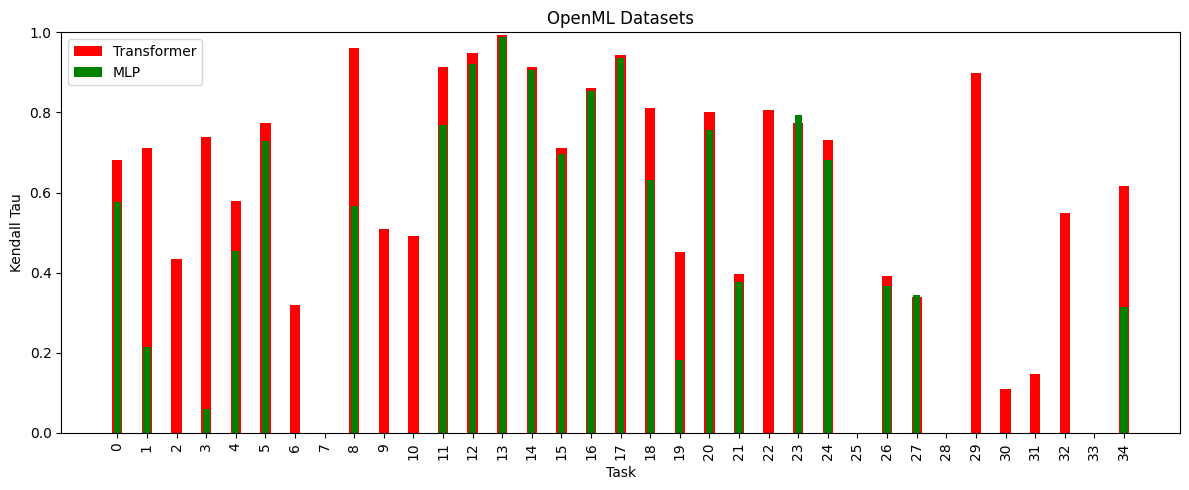

In [31]:
import matplotlib.pyplot as plt
import numpy as np

datasets = list(transformer_results.keys())
mlp_taus = [mlp_results[ds]['tau'] for ds in datasets]
transformer_taus = [transformer_results[ds]['tau'] for ds in datasets]

x = np.arange(len(datasets))
bar_width = 0.35

plt.figure(figsize=(12, 5))
# Base bars (e.g. Transformer)
plt.bar(x, transformer_taus, color='red', width=bar_width, label='Transformer')

# Overlay bars (e.g. MLP), slightly narrower to show both
plt.bar(x, mlp_taus, color='green', width=bar_width * 0.7, label='MLP')

plt.xticks(x, datasets, rotation=90)
plt.xlabel('Task')
plt.ylabel('Kendall Tau')
plt.title('OpenML Datasets')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
import json

combined = {
    "transformer": transformer_results,
    "mlp": mlp_results
}

with open("pml_results_15_34.json", "w") as f:
    json.dump(combined, f, indent=2)

print("Saved all results to benchmark_results.json")

Saved all results to benchmark_results.json


In [33]:
print(f"total time taken {time.time()-t1} seconds")

total time taken 4286.537606954575 seconds
